In [13]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Download latest version
path = kagglehub.dataset_download("srisyra02/e-commerce-sales-performance-analysis")
csv_files = list(Path(path).glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {path}")

df = pd.read_csv(csv_files[0])


In [14]:
df.shape

(5000, 12)

In [15]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [16]:
df.tail()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38
4999,15000,9/9/2035,1214,Home,East,7,231.58,0.34,COD,5,3.9,1069.90


In [17]:
# Drop incomplete order data from 2035
df['order_date'] = pd.to_datetime(df['order_date'])
df = df[df['order_date'].dt.year != 2035].copy()

In [18]:
df

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56
...,...,...,...,...,...,...,...,...,...,...,...,...
4743,14744,2034-12-27,1277,Electronics,West,6,302.12,0.34,Card,6,3.7,1196.40
4744,14745,2034-12-28,1067,Clothing,North,2,277.13,0.18,COD,11,4.0,454.49
4745,14746,2034-12-29,1068,Electronics,West,5,584.38,0.26,Card,10,4.1,2162.21
4746,14747,2034-12-30,1164,Beauty,West,6,594.37,0.24,Card,6,3.6,2710.33


## 1. What is the total revenue, total number of orders, and average order value?

In [19]:
# Question 1: Core sales KPIs
total_revenue = df['revenue'].sum()
total_orders = df['order_id'].nunique()
average_order_value = total_revenue / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")

Total Revenue: $4,871,042.38
Total Orders: 4,748
Average Order Value: $1,025.91


## 2. Which product categories generate the most revenue and sales quantity?

In [20]:
df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

product_category
Electronics    1748795.42
Clothing       1447304.19
Home            937269.33
Beauty          737673.44
Name: revenue, dtype: float64

## 3. Which regions have the strongest sales performance by revenue, order volume, and average order value?


In [21]:
# Question 3: Sales performance by region
region_kpis = (
    df.groupby('region')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_orders=('order_id', 'nunique'),
        total_quantity=('quantity', 'sum')
    )
    .assign(
        average_order_value=lambda data: (
            data['total_revenue'] / data['total_orders']
        ).round(2)
    )
    .sort_values('total_revenue', ascending=False)
)

# Format total revenue for display
region_kpis_display = region_kpis.copy()
region_kpis_display['total_revenue'] = region_kpis_display['total_revenue'].map('${:,.2f}'.format)

region_kpis_display

,total_revenue,total_orders,total_quantity,average_order_value
region,,,,
West,"$1,287,852.11",1225,5026,1051.31
North,"$1,227,993.62",1218,4926,1008.20
South,"$1,179,983.16",1144,4611,1031.45
East,"$1,175,213.49",1161,4648,1012.24


## 4. How do monthly revenue and order volume change over time, and are there any clear seasonal peaks or declines?


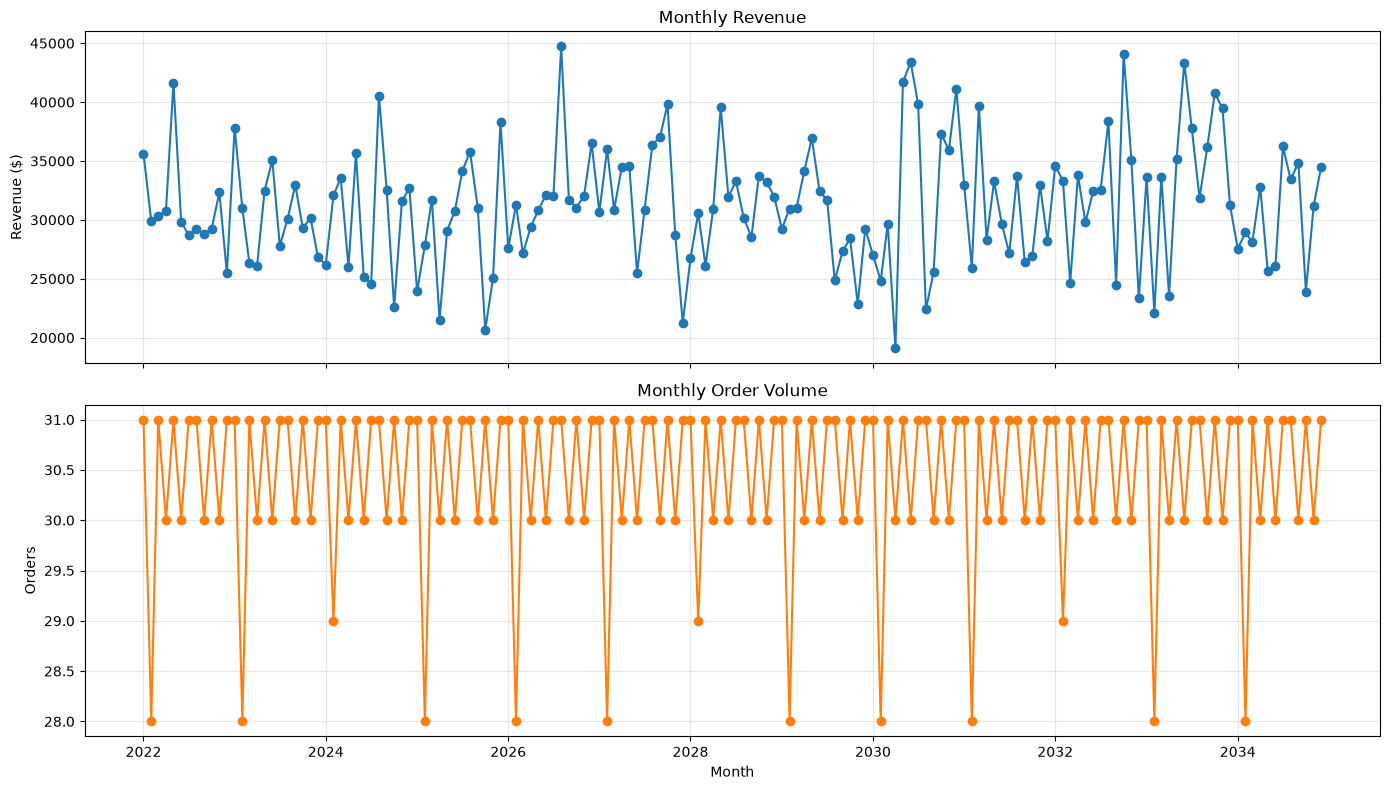

Highest revenue: Aug 2026 ($44,728.82)
Lowest revenue: Apr 2030 ($19,101.90)
Highest order volume: Jan 2022 (31 orders)
Lowest order volume: Feb 2022 (28 orders)

Note: This dataset has one observation per day across a long time span, so each month has a different number of observations. The chart shows monthly variation; it is not enough on its own to establish recurring seasonality.


In [22]:
# Question 4: Monthly revenue and order-volume trend
df['order_date'] = pd.to_datetime(df['order_date'])
monthly_kpis = (
    df.assign(month=df['order_date'].dt.to_period('M').dt.to_timestamp())
      .groupby('month')
      .agg(
          total_revenue=('revenue', 'sum'),
          total_orders=('order_id', 'nunique')
      )
      .sort_index()
)

monthly_kpis['total_revenue'] = monthly_kpis['total_revenue'].round(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True) # all subplot share same axis

axes[0].plot(monthly_kpis.index, monthly_kpis['total_revenue'], marker='o', linewidth=1.5)
axes[0].set_title('Monthly Revenue')
axes[0].set_ylabel('Revenue ($)')
axes[0].grid(alpha=0.3)

axes[1].plot(monthly_kpis.index, monthly_kpis['total_orders'], marker='o', color='tab:orange', linewidth=1.5)
axes[1].set_title('Monthly Order Volume')
axes[1].set_ylabel('Orders')
axes[1].set_xlabel('Month')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

peak_revenue_month = monthly_kpis['total_revenue'].idxmax()
low_revenue_month = monthly_kpis['total_revenue'].idxmin()
peak_orders_month = monthly_kpis['total_orders'].idxmax()
low_orders_month = monthly_kpis['total_orders'].idxmin()

print(f"Highest revenue: {peak_revenue_month:%b %Y} (${monthly_kpis.loc[peak_revenue_month, 'total_revenue']:,.2f})")
print(f"Lowest revenue: {low_revenue_month:%b %Y} (${monthly_kpis.loc[low_revenue_month, 'total_revenue']:,.2f})")
print(f"Highest order volume: {peak_orders_month:%b %Y} ({monthly_kpis.loc[peak_orders_month, 'total_orders']:,} orders)")
print(f"Lowest order volume: {low_orders_month:%b %Y} ({monthly_kpis.loc[low_orders_month, 'total_orders']:,} orders)")
print("\nNote: This dataset has one observation per day across a long time span, so each month has a different number of observations. The chart shows monthly variation; it is not enough on its own to establish recurring seasonality.")

## 5. How do discount levels affect revenue, quantity sold, and average order value across product categories?


,product_category,discount_band,total_revenue,quantity_sold,average_order_value,orders
0,Beauty,0–9%,"$215,618.83",723,"$1,314.75",164
1,Beauty,10–19%,"$217,876.91",842,"$1,052.55",207
2,Beauty,20–29%,"$205,391.42",886,$973.42,211
3,Beauty,30%+,"$98,786.28",443,$882.02,112
4,Clothing,0–9%,"$388,683.39",1367,"$1,120.13",347
5,Clothing,10–19%,"$402,422.23",1553,"$1,018.79",395
6,Clothing,20–29%,"$440,123.02",1832,$982.42,448
7,Clothing,30%+,"$216,075.55",1027,$871.27,248
8,Electronics,0–9%,"$530,653.20",1788,"$1,208.78",439
9,Electronics,10–19%,"$538,122.28",2022,"$1,059.30",508


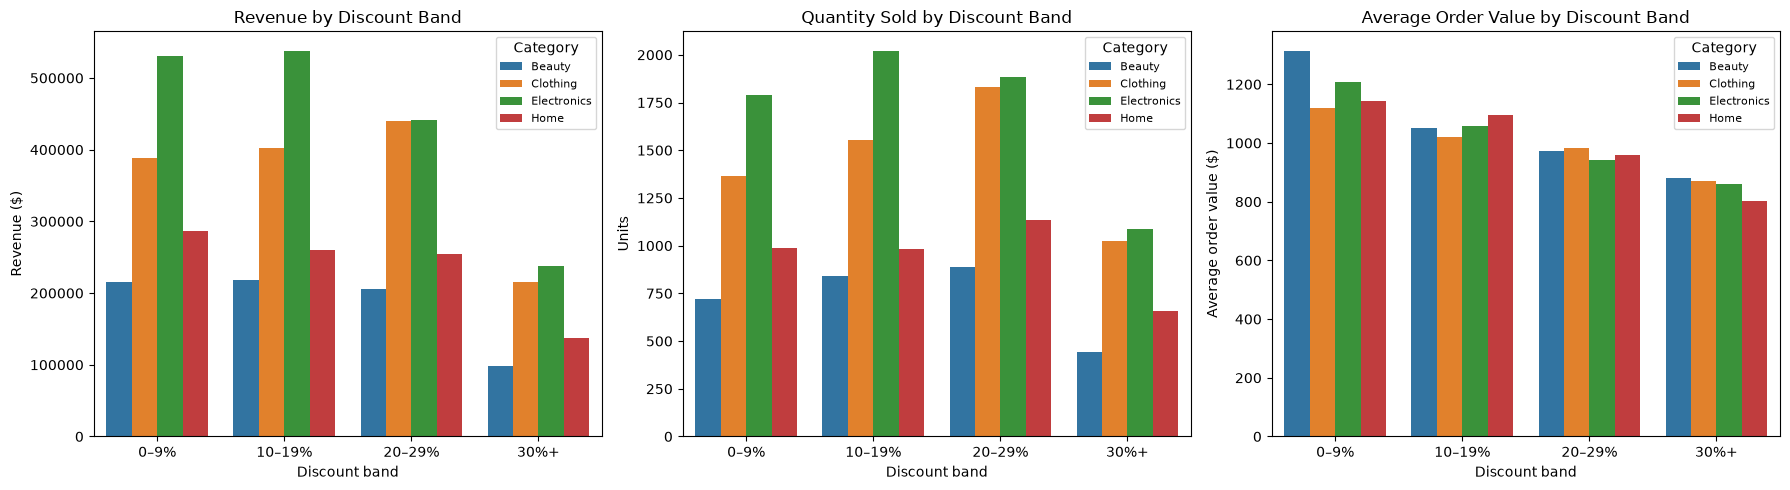

Highest average order value: Beauty at 0–9% discount ($1,314.75)
Highest total revenue: Electronics at 10–19% discount ($538,122.28)
Interpretation: these results are descriptive; discount bands may reflect product mix and demand, so they do not by themselves prove causation.


In [23]:
# Question 5: Discount impact by product category
discount_labels = ['0–9%', '10–19%', '20–29%', '30%+']
df['discount_band'] = pd.cut(
    df['discount'],
    bins=[-0.01, 0.09, 0.19, 0.29, 1.00],
    labels=discount_labels
)

discount_category_kpis = (
    df.groupby(['product_category', 'discount_band'], observed=False)
      .agg(total_revenue=('revenue', 'sum'),
           quantity_sold=('quantity', 'sum'),
           average_order_value=('revenue', 'mean'),
           orders=('order_id', 'nunique'))
      .reset_index()
)

display_kpis = discount_category_kpis.copy()
display_kpis['total_revenue'] = display_kpis['total_revenue'].map('${:,.2f}'.format)
display_kpis['average_order_value'] = display_kpis['average_order_value'].map('${:,.2f}'.format)
display(display_kpis)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=discount_category_kpis, x='discount_band', y='total_revenue', hue='product_category', ax=axes[0])
sns.barplot(data=discount_category_kpis, x='discount_band', y='quantity_sold', hue='product_category', ax=axes[1])
sns.barplot(data=discount_category_kpis, x='discount_band', y='average_order_value', hue='product_category', ax=axes[2])

for ax, title, ylabel in zip(
    axes,
    ['Revenue by Discount Band', 'Quantity Sold by Discount Band', 'Average Order Value by Discount Band'],
    ['Revenue ($)', 'Units', 'Average order value ($)']
):
    ax.set_title(title)
    ax.set_xlabel('Discount band')
    ax.set_ylabel(ylabel)
    ax.legend(title='Category', fontsize=8)

plt.tight_layout()
plt.show()

best_aov = discount_category_kpis.loc[discount_category_kpis['average_order_value'].idxmax()]
best_revenue = discount_category_kpis.loc[discount_category_kpis['total_revenue'].idxmax()]
print(f"Highest average order value: {best_aov['product_category']} at {best_aov['discount_band']} discount (${best_aov['average_order_value']:,.2f})")
print(f"Highest total revenue: {best_revenue['product_category']} at {best_revenue['discount_band']} discount (${best_revenue['total_revenue']:,.2f})")
print('Interpretation: these results are descriptive; discount bands may reflect product mix and demand, so they do not by themselves prove causation.')

## 6. Which combinations of product category, region, payment method, delivery time, and customer rating offer the best opportunities to improve revenue and customer experience?

In [24]:
# Question 6: High-impact opportunities to improve revenue and customer experience
df['delivery_tier'] = pd.cut(
    df['delivery_days'],
    bins=[0, 3, 7, np.inf],
    labels=['Fast (1–3 days)', 'Standard (4–7 days)', 'Slow (8+ days)'],
    include_lowest=True
)
df['rating_tier'] = pd.cut(
    df['customer_rating'],
    bins=[0, 3.4, 4.4, 5.0],
    labels=['Low (≤3.4)', 'Medium (3.5–4.4)', 'High (4.5+)'],
    include_lowest=True
)

segment_kpis = (
    df.groupby(
        ['product_category', 'region', 'payment_method', 'delivery_tier', 'rating_tier'],
        observed=False
    )
      .agg(total_revenue=('revenue', 'sum'),
           orders=('order_id', 'nunique'),
           average_order_value=('revenue', 'mean'),
           average_delivery_days=('delivery_days', 'mean'),
           average_rating=('customer_rating', 'mean'))
      .reset_index()
)

# Score segments that combine meaningful revenue with slow delivery and/or weak ratings.
revenue_share = segment_kpis['total_revenue'] / segment_kpis['total_revenue'].sum()
delivery_gap = (segment_kpis['average_delivery_days'] - df['delivery_days'].mean()).clip(lower=0)
rating_gap = (df['customer_rating'].mean() - segment_kpis['average_rating']).clip(lower=0)
segment_kpis['opportunity_score'] = revenue_share * (1 + delivery_gap + rating_gap)

opportunities = (
    segment_kpis.query('orders >= 5')
      .sort_values(['opportunity_score', 'total_revenue'], ascending=False)
      .head(10)
      .copy()
)

display_opportunities = opportunities.copy()
display_opportunities['total_revenue'] = display_opportunities['total_revenue'].map('${:,.2f}'.format)
display_opportunities['average_order_value'] = display_opportunities['average_order_value'].map('${:,.2f}'.format)
display_opportunities['average_delivery_days'] = display_opportunities['average_delivery_days'].round(1)
display_opportunities['average_rating'] = display_opportunities['average_rating'].round(2)
display_opportunities['opportunity_score'] = display_opportunities['opportunity_score'].round(3)
display(display_opportunities)

print('Recommended focus: prioritize the highest-scoring segments above—especially those marked Slow (8+ days) or Low (≤3.4) rating.')
print('The score is a prioritization aid, not a causal estimate: it weights revenue exposure alongside slower delivery and below-average ratings.')

,product_category,region,payment_method,delivery_tier,rating_tier,total_revenue,orders,average_order_value,average_delivery_days,average_rating,opportunity_score
285,Electronics,South,Card,Slow (8+ days),Low (≤3.4),"$52,424.15",48,"$1,092.17",9.4,2.30,0.053
276,Electronics,South,COD,Slow (8+ days),Low (≤3.4),"$47,119.86",47,"$1,002.55",9.7,2.48,0.049
123,Clothing,East,Card,Slow (8+ days),Low (≤3.4),"$42,201.24",38,"$1,110.56",9.9,2.19,0.048
312,Electronics,West,Card,Slow (8+ days),Low (≤3.4),"$43,204.39",33,"$1,309.22",9.4,2.12,0.046
114,Clothing,East,COD,Slow (8+ days),Low (≤3.4),"$44,035.14",38,"$1,158.82",9.5,2.33,0.045
231,Electronics,East,Card,Slow (8+ days),Low (≤3.4),"$46,590.40",44,"$1,058.87",9.2,2.36,0.045
222,Electronics,East,COD,Slow (8+ days),Low (≤3.4),"$38,568.18",42,$918.29,9.6,2.21,0.041
204,Clothing,West,Card,Slow (8+ days),Low (≤3.4),"$34,842.01",41,$849.81,9.8,2.01,0.041
141,Clothing,North,COD,Slow (8+ days),Low (≤3.4),"$34,980.75",30,"$1,166.03",9.9,2.17,0.040
330,Home,East,COD,Slow (8+ days),Low (≤3.4),"$35,078.64",34,"$1,031.72",9.5,1.98,0.039


Recommended focus: prioritize the highest-scoring segments above—especially those marked Slow (8+ days) or Low (≤3.4) rating.
The score is a prioritization aid, not a causal estimate: it weights revenue exposure alongside slower delivery and below-average ratings.
